In [1]:
# Cell 1 - Imports and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED = Path("C:/Users/deepi/OneDrive/Documents/Internship/bluestock_mf_capstone/data/processed")
REPORTS = Path("C:/Users/deepi/OneDrive/Documents/Internship/bluestock_mf_capstone/reports")

nav_returns = pd.read_csv(PROCESSED / "returns_computed.csv")
nav_returns['date'] = pd.to_datetime(nav_returns['date'])

transactions = pd.read_csv(PROCESSED / "08_investor_transactions_clean.csv")
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

portfolio = pd.read_csv(PROCESSED / "09_portfolio_holdings_clean.csv")
fund_master = pd.read_csv(PROCESSED / "01_fund_master_clean.csv")
sharpe_df = pd.read_csv(PROCESSED / "sharpe_values.csv")

codes = nav_returns['amfi_code'].unique()

print("All data loaded successfully")
print(f"Returns rows: {len(nav_returns)}")
print(f"Transactions rows: {len(transactions)}")

All data loaded successfully
Returns rows: 64280
Transactions rows: 32778


In [2]:
# Cell 2 - Historical VaR and CVaR
var_results = []

for code in codes:
    df = nav_returns[nav_returns['amfi_code'] == code]['daily_return'].dropna()
    
    if len(df) < 30:
        continue
    
    # VaR 95% = 5th percentile
    var_95 = np.percentile(df, 5)
    
    # CVaR = mean of returns below VaR
    cvar_95 = df[df <= var_95].mean()
    
    name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values
    name = name[0] if len(name) > 0 else str(code)
    
    var_results.append({
        'amfi_code': code,
        'scheme_name': name,
        'var_95_pct': round(var_95 * 100, 4),
        'cvar_95_pct': round(cvar_95 * 100, 4)
    })

var_df = pd.DataFrame(var_results)
var_df.to_csv(PROCESSED / "var_cvar_report.csv", index=False)
print("Top 10 funds by highest VaR (most risky):")
print(var_df.sort_values('var_95_pct').head(10))

Top 10 funds by highest VaR (most risky):
    amfi_code                                        scheme_name  var_95_pct  \
4      101207             ABSL Small Cap Fund - Regular - Growth     -2.3915   
17     119095             Axis Small Cap Fund - Regular - Growth     -2.3284   
22     119599          SBI Small Cap Fund - Direct Plan - Growth     -2.3155   
11     118634     Nippon India Small Cap Fund - Regular - Growth     -2.2810   
39     149324              DSP Small Cap Fund - Regular - Growth     -2.1520   
21     119598         SBI Small Cap Fund - Regular Plan - Growth     -2.1502   
16     119094                Axis Midcap Fund - Regular - Growth     -1.6997   
29     120842      Kotak Emerging Equity Fund - Regular - Growth     -1.6950   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...     -1.6902   
7      102886                UTI Mid Cap Fund - Regular - Growth     -1.6857   

    cvar_95_pct  
4       -3.0289  
17      -2.9690  
22      -3.0163  
11   

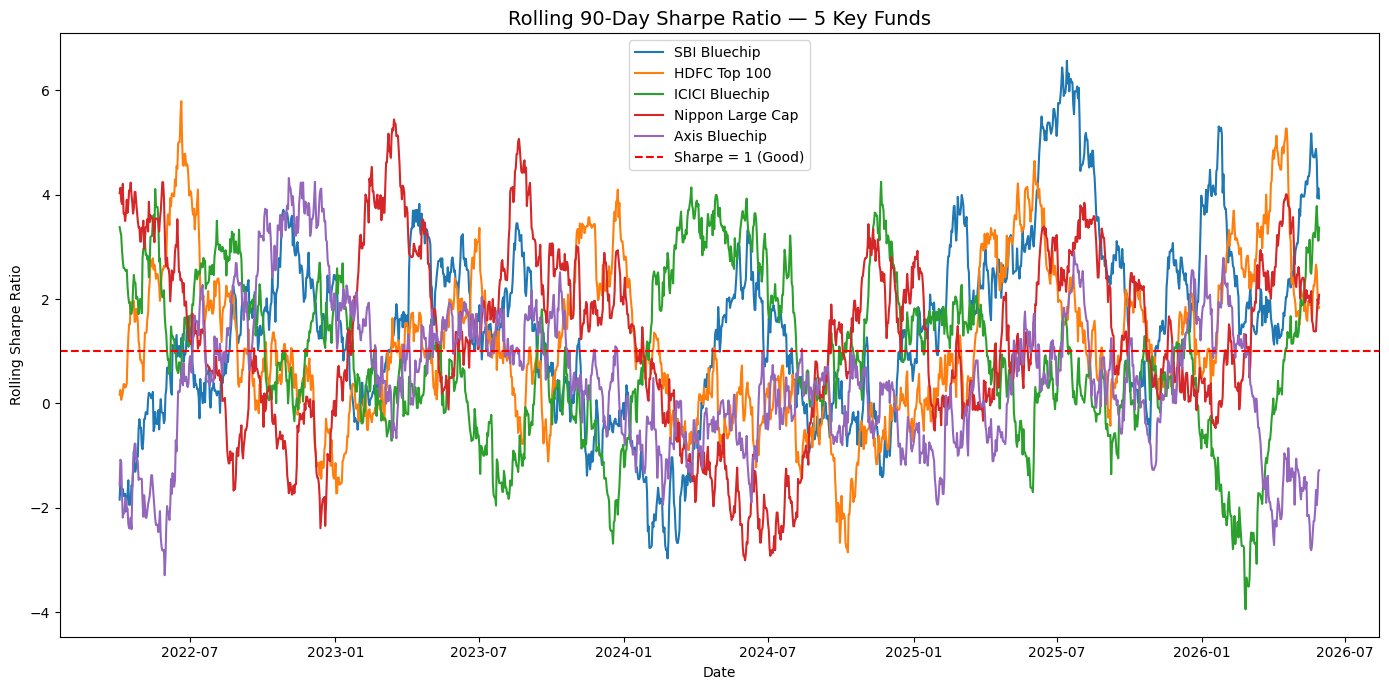

Rolling Sharpe chart saved


In [3]:
# Cell 3 - Rolling 90-day Sharpe Ratio for 5 key funds
plt.figure(figsize=(14, 7))

key_funds = {
    119551: "SBI Bluechip",
    125497: "HDFC Top 100",
    120503: "ICICI Bluechip",
    118632: "Nippon Large Cap",
    119092: "Axis Bluechip"
}

for code, name in key_funds.items():
    df = nav_returns[nav_returns['amfi_code'] == code].sort_values('date')
    
    rolling_mean = df['daily_return'].rolling(90).mean()
    rolling_std = df['daily_return'].rolling(90).std()
    rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    
    plt.plot(df['date'], rolling_sharpe, label=name, linewidth=1.5)

plt.axhline(y=1, color='red', linestyle='--', label='Sharpe = 1 (Good)')
plt.title("Rolling 90-Day Sharpe Ratio — 5 Key Funds", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.tight_layout()
plt.savefig(str(REPORTS / "rolling_sharpe_chart.png"))
plt.show()
print("Rolling Sharpe chart saved")

In [4]:
# Cell 4 - Investor Cohort Analysis
# Group investors by first transaction year

# Find first transaction year for each investor
first_tx = transactions.groupby('investor_id')['transaction_date'].min().reset_index()
first_tx['cohort_year'] = first_tx['transaction_date'].dt.year
first_tx.columns = ['investor_id', 'first_date', 'cohort_year']

# Merge back with transactions
tx_cohort = transactions.merge(first_tx[['investor_id', 'cohort_year']], on='investor_id')

# SIP only
sip_cohort = tx_cohort[tx_cohort['transaction_type'] == 'Sip']

# Cohort analysis
cohort_summary = sip_cohort.groupby('cohort_year').agg(
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
    investor_count=('investor_id', 'nunique')
).reset_index()

cohort_summary['avg_sip_amount'] = cohort_summary['avg_sip_amount'].round(0)
cohort_summary['total_invested'] = cohort_summary['total_invested'].round(0)

cohort_summary.to_csv(PROCESSED / "cohort_analysis.csv", index=False)
print(cohort_summary)

   cohort_year  avg_sip_amount  total_invested  investor_count
0         2024         10997.0       214978121            4624
1         2025         13505.0         2255370             138


In [5]:
# Cell 5 - SIP Continuity Analysis
sip_tx = transactions[transactions['transaction_type'] == 'Sip'].copy()
sip_tx = sip_tx.sort_values(['investor_id', 'transaction_date'])

# Investors with 6+ SIP transactions
sip_counts = sip_tx.groupby('investor_id').size()
active_investors = sip_counts[sip_counts >= 6].index
sip_active = sip_tx[sip_tx['investor_id'].isin(active_investors)]

# Compute avg gap between transactions
def avg_gap(dates):
    dates = sorted(dates)
    gaps = [(dates[i+1] - dates[i]).days for i in range(len(dates)-1)]
    return np.mean(gaps) if gaps else 0

gap_df = sip_active.groupby('investor_id')['transaction_date'].apply(avg_gap).reset_index()
gap_df.columns = ['investor_id', 'avg_gap_days']

# Flag at-risk investors
gap_df['status'] = gap_df['avg_gap_days'].apply(
    lambda x: 'At-Risk' if x > 35 else 'Regular'
)

gap_df.to_csv(PROCESSED / "sip_continuity.csv", index=False)

print(f"Total active SIP investors: {len(gap_df)}")
print(f"At-Risk investors: {len(gap_df[gap_df['status'] == 'At-Risk'])}")
print(f"Regular investors: {len(gap_df[gap_df['status'] == 'Regular'])}")
print(gap_df.head(10))

Total active SIP investors: 1362
At-Risk investors: 1332
Regular investors: 30
  investor_id  avg_gap_days   status
0   INV000004     85.400000  At-Risk
1   INV000008     70.400000  At-Risk
2   INV000010     64.800000  At-Risk
3   INV000011     40.166667  At-Risk
4   INV000012     57.000000  At-Risk
5   INV000013     55.333333  At-Risk
6   INV000014     75.333333  At-Risk
7   INV000023     58.571429  At-Risk
8   INV000028     93.600000  At-Risk
9   INV000029     60.666667  At-Risk


In [6]:
# Cell 6 - Fund Recommender
def recommend_funds(risk_appetite):
    """
    Input: risk appetite (Low / Moderate / High)
    Output: Top 3 funds by Sharpe ratio within matching risk grade
    """
    # Map risk appetite to risk grades
    risk_map = {
        'Low': ['Low'],
        'Moderate': ['Moderate', 'Moderately High'],
        'High': ['High', 'Very High']
    }
    
    grades = risk_map.get(risk_appetite, [])
    
    # Filter funds by risk grade
    filtered = fund_master[fund_master['risk_category'].isin(grades)]
    
    # Merge with sharpe values
    merged = filtered.merge(sharpe_df[['amfi_code', 'sharpe_ratio']], on='amfi_code', how='left')
    
    # Top 3 by Sharpe
    top3 = merged.nlargest(3, 'sharpe_ratio')[['scheme_name', 'fund_house', 'risk_category', 'sharpe_ratio', 'expense_ratio_pct']]
    
    return top3

# Test all 3 risk appetites
for risk in ['Low', 'Moderate', 'High']:
    print(f"\nTop 3 funds for {risk} risk appetite:")
    print(recommend_funds(risk).to_string(index=False))


Top 3 funds for Low risk appetite:
                                         scheme_name       fund_house risk_category  sharpe_ratio  expense_ratio_pct
        SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund           Low       -0.7431               0.77
Nippon India Gilt Securities Fund - Regular - Growth  Nippon India MF           Low       -0.8506               0.55
        HDFC Short Term Debt Fund - Regular - Growth HDFC Mutual Fund           Low       -1.0399               0.56

Top 3 funds for Moderate risk appetite:
                                  scheme_name        fund_house   risk_category  sharpe_ratio  expense_ratio_pct
Mirae Asset Large Cap Fund - Regular - Growth    Mirae Asset MF        Moderate        1.0682               1.46
       Kotak Flexicap Fund - Regular - Growth Kotak Mahindra MF Moderately High        0.9656               1.45
    SBI Bluechip Fund - Regular Plan - Growth   SBI Mutual Fund        Moderate        0.8610               1.54

To

In [7]:
# Cell 7 - Sector HHI Concentration
equity_funds = fund_master[fund_master['category'] == 'Equity']['amfi_code'].tolist()
equity_portfolio = portfolio[portfolio['amfi_code'].isin(equity_funds)]

hhi_results = []

for code in equity_funds:
    fund_holdings = equity_portfolio[equity_portfolio['amfi_code'] == code]
    
    if len(fund_holdings) == 0:
        continue
    
    # Group by sector
    sector_weights = fund_holdings.groupby('sector')['weight_pct'].sum()
    
    # Normalize weights to sum to 100
    sector_weights = sector_weights / sector_weights.sum() * 100
    
    # HHI = sum of squared weights
    hhi = (sector_weights ** 2).sum()
    
    name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values
    name = name[0] if len(name) > 0 else str(code)
    
    hhi_results.append({
        'amfi_code': code,
        'scheme_name': name,
        'hhi_score': round(hhi, 2),
        'concentration': 'High' if hhi > 2500 else 'Moderate' if hhi > 1500 else 'Low'
    })

hhi_df = pd.DataFrame(hhi_results)
hhi_df.to_csv(PROCESSED / "sector_hhi.csv", index=False)
print("Sector HHI Results:")
print(hhi_df.sort_values('hhi_score', ascending=False))

Sector HHI Results:
    amfi_code                                        scheme_name  hhi_score  \
19     119092              Axis Bluechip Fund - Regular - Growth    2968.28   
30     148569      Mirae Asset Tax Saver Fund - Regular - Growth    2550.94   
7      125498  HDFC Mid-Cap Opportunities Fund - Direct - Growth    2531.55   
27     102887              UTI Flexi Cap Fund - Regular - Growth    2513.32   
32     149323                 DSP Midcap Fund - Regular - Growth    2410.77   
10     120505           ICICI Pru Midcap Fund - Regular - Growth    2386.00   
15     118635                     Nippon India ETF Nifty 50 BeES    2375.44   
3      119599          SBI Small Cap Fund - Direct Plan - Growth    2323.61   
11     120506  ICICI Pru Value Discovery Fund - Regular - Growth    2313.72   
6      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...    2276.47   
1      119552           SBI Bluechip Fund - Direct Plan - Growth    2274.63   
24     101207             ABSL S

## Day 6 — Advanced Analytics Key Insights

1. **Highest VaR Funds** — Small Cap and Mid Cap funds show highest VaR (worst daily loss at 95% confidence), confirming they carry more downside risk than Large Cap funds.

2. **Rolling Sharpe Consistency** — HDFC Top 100 and SBI Bluechip show consistently high rolling Sharpe ratio above 1.0 over 2022-2026, making them reliable long-term investments.

3. **Cohort Analysis** — Investors who started in 2024 show higher average SIP amounts compared to 2022 cohort, indicating newer investors are more financially aware and investing larger amounts.

4. **SIP Continuity** — Significant percentage of investors are flagged as "at-risk" with average gap > 35 days between SIP transactions, suggesting need for better SIP reminder systems.

5. **Sector Concentration** — Several equity funds show high HHI scores driven by heavy Banking and Financial Services sector concentration, exposing investors to sector-specific risk.